# CS412 Machine Learning

## Homework: Text Classification and Word Embeddings

**Total: 100 points**

This notebook has two questions:

- **Question 1: Word Embeddings with Pre-trained GloVe** - 50 points
- **Question 2: Sentiment Classification with Multinomial Naive Bayes** - 50 points

### Important rule
Each task must be completed in its **respective code cell**. For example, the work for **Cell 1.2** must appear in the code cell labeled **Cell 1.2**. Do not merge multiple tasks into one cell.

Before submission, run all cells and keep all outputs visible in the notebook.

## General Imports

Run this cell before starting the assignment. You may add small utility imports here if needed, but the graded task code should remain inside the corresponding task cells.

In [1]:
# If gensim is not installed, uncomment and run the following line:
!pip install gensim

import re
import string
import zipfile
from io import BytesIO
from urllib.request import urlopen, Request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.manifold import TSNE

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.8 MB/s eta 0:00:00


# Question 1 - Word Embeddings with Pre-trained GloVe

**50 points total**

In this question, you will use pre-trained GloVe word embeddings. You will load a selected vocabulary, compute cosine similarities, find nearest neighbors, solve simple analogies, and visualize selected embeddings using t-SNE.

## Cell 1.1 - Load GloVe Embeddings

**10 points**

**Goal:** Load `glove-wiki-gigaword-50` using `gensim.downloader`, create a `word_to_vec` dictionary for the selected words, and print basic information about the embeddings.

In [2]:
# Cell 1.1 - Load GloVe Embeddings

import gensim.downloader as api

selected_words = [
    # people / gender / royalty
    "king", "queen", "man", "woman", "boy", "girl",
    "prince", "princess", "actor", "actress",

    # vehicles
    "car", "automobile", "truck", "bus", "train", "bicycle", "road",

    # animals
    "dog", "cat", "puppy", "kitten", "lion", "tiger",

    # sentiment words
    "good", "great", "excellent", "amazing", "fun", "enjoyable",
    "bad", "awful", "terrible", "boring", "dull", "poor",

    # food
    "pizza", "burger", "sushi", "pasta", "cake", "coffee", "banana",

    # movie-related words
    "movie", "film", "cinema", "story", "plot", "soundtrack",

    # countries and capitals
    "france", "paris", "italy", "rome", "turkey", "ankara",
    "japan", "tokyo", "germany", "berlin"
]

glove = api.load("glove-wiki-gigaword-50")

word_to_vec = {
    word: glove[word]
    for word in selected_words
    if word in glove
}

print(f"Number of selected words loaded: {len(word_to_vec)}")
print(f"Embedding dimension: {len(next(iter(word_to_vec.values())))}")
print("First 10 loaded words:")
print(list(word_to_vec.keys())[:10])


[==================================================] 100.0% 66.0/66.0MB downloaded
Number of selected words loaded: 58
Embedding dimension: 50
First 10 loaded words:
['king', 'queen', 'man', 'woman', 'boy', 'girl', 'prince', 'princess', 'actor', 'actress']


## Cell 1.2 - Implement Cosine Similarity

**10 points**

**Goal:** Implement cosine similarity manually using NumPy and compare several word pairs.

In [3]:
# Cell 1.2 - Implement Cosine Similarity

def cosine_similarity(vec1, vec2):
    """
    Compute cosine similarity between two vectors.

    cosine(a, b) = (a dot b) / (||a|| ||b||)
    """
    vec1 = np.array(vec1)
    vec2 = np.array(vec2)

    denominator = np.linalg.norm(vec1) * np.linalg.norm(vec2)

    if denominator == 0:
        return 0.0

    return float(np.dot(vec1, vec2) / denominator)


word_pairs = [
    ("king", "queen"),
    ("man", "woman"),
    ("car", "automobile"),
    ("car", "banana"),
    ("good", "excellent"),
    ("good", "terrible"),
]

for w1, w2 in word_pairs:
    similarity = cosine_similarity(word_to_vec[w1], word_to_vec[w2])
    print(f"{w1:12s} - {w2:12s}: {similarity:.4f}")


king         - queen       : 0.7839
man          - woman       : 0.8860
car          - automobile  : 0.6956
car          - banana      : 0.2190
good         - excellent   : 0.8062
good         - terrible    : 0.5951


## Cell 1.3 - Find Nearest Neighbors

**10 points**

**Goal:** Implement a nearest-neighbor function that returns the most similar selected words to a query word using cosine similarity.

In [4]:
# Cell 1.3 - Find Nearest Neighbors

def nearest_neighbors(word, k=5):
    """
    Return the k nearest words to the query word using cosine similarity.
    Search is restricted to the selected vocabulary in word_to_vec.
    """
    if word not in word_to_vec:
        raise ValueError(f"{word} not found in vocabulary.")

    query_vec = word_to_vec[word]
    similarities = []

    for candidate, candidate_vec in word_to_vec.items():
        if candidate == word:
            continue

        sim = cosine_similarity(query_vec, candidate_vec)
        similarities.append((candidate, sim))

    similarities.sort(key=lambda x: x[1], reverse=True)

    return similarities[:k]


test_words = ["king", "car", "good", "movie", "dog"]

for word in test_words:
    print(f"\nNearest neighbors for '{word}':")
    for neighbor, score in nearest_neighbors(word, k=5):
        print(f"  {neighbor:12s} -> {score:.4f}")



Nearest neighbors for 'king':
  prince       -> 0.8236
  queen        -> 0.7839
  great        -> 0.6681
  princess     -> 0.6023
  man          -> 0.5309

Nearest neighbors for 'car':
  truck        -> 0.9209
  bus          -> 0.8211
  train        -> 0.7658
  bicycle      -> 0.7560
  automobile   -> 0.6956

Nearest neighbors for 'good':
  excellent    -> 0.8062
  fun          -> 0.8031
  great        -> 0.7983
  bad          -> 0.7965
  man          -> 0.7270

Nearest neighbors for 'movie':
  film         -> 0.9310
  story        -> 0.7691
  soundtrack   -> 0.7653
  actor        -> 0.7566
  cinema       -> 0.7235

Nearest neighbors for 'dog':
  cat          -> 0.9218
  puppy        -> 0.7755
  boy          -> 0.7383
  man          -> 0.7122
  girl         -> 0.6774


## Cell 1.4 - Word Analogy Arithmetic

**10 points**

**Goal:** Solve simple analogies using vector arithmetic of the form `b - a + c` and nearest-neighbor search.

In [5]:
# Cell 1.4 - Word Analogy Arithmetic

def analogy(a, b, c, k=5):
    """
    Solve analogies of the form:
    a is to b as c is to ?

    target = vector(b) - vector(a) + vector(c)
    """
    for word in [a, b, c]:
        if word not in word_to_vec:
            raise ValueError(f"{word} not found in vocabulary.")

    target_vector = word_to_vec[b] - word_to_vec[a] + word_to_vec[c]

    similarities = []

    for candidate, candidate_vec in word_to_vec.items():
        if candidate in [a, b, c]:
            continue

        sim = cosine_similarity(target_vector, candidate_vec)
        similarities.append((candidate, sim))

    similarities.sort(key=lambda x: x[1], reverse=True)

    return similarities[:k]


analogy_examples = [
    ("man", "king", "woman"),
    ("boy", "girl", "man"),
    ("france", "paris", "italy"),
    ("japan", "tokyo", "germany"),
    ("bad", "terrible", "good"),
]

for a, b, c in analogy_examples:
    print(f"\n{a} : {b} :: {c} : ?")
    results = analogy(a, b, c, k=5)

    for candidate, score in results:
        print(f"  {candidate:12s} -> {score:.4f}")

print("\nInterpretation:")
print("The embeddings capture semantic relationships such as country-capital and gender relationships.")



man : king :: woman : ?
  queen        -> 0.8610
  prince       -> 0.7641
  princess     -> 0.7513
  great        -> 0.5244
  girl         -> 0.5142

boy : girl :: man : ?
  woman        -> 0.9389
  story        -> 0.6847
  good         -> 0.6713
  dog          -> 0.6589
  actress      -> 0.6221

france : paris :: italy : ?
  rome         -> 0.8379
  berlin       -> 0.6611
  cinema       -> 0.5548
  germany      -> 0.5433
  tokyo        -> 0.5253

japan : tokyo :: germany : ?
  berlin       -> 0.8657
  paris        -> 0.7541
  france       -> 0.6159
  rome         -> 0.5943
  italy        -> 0.5272

bad : terrible :: good : ?
  amazing      -> 0.7628
  great        -> 0.7557
  awful        -> 0.7174
  fun          -> 0.6507
  man          -> 0.6325

Interpretation:
The embeddings capture semantic relationships such as country-capital and gender relationships.


## Cell 1.5 - Visualize Selected Embeddings with t-SNE

**10 points**

**Goal:** Project selected GloVe vectors to two dimensions using t-SNE and create a labeled scatter plot.

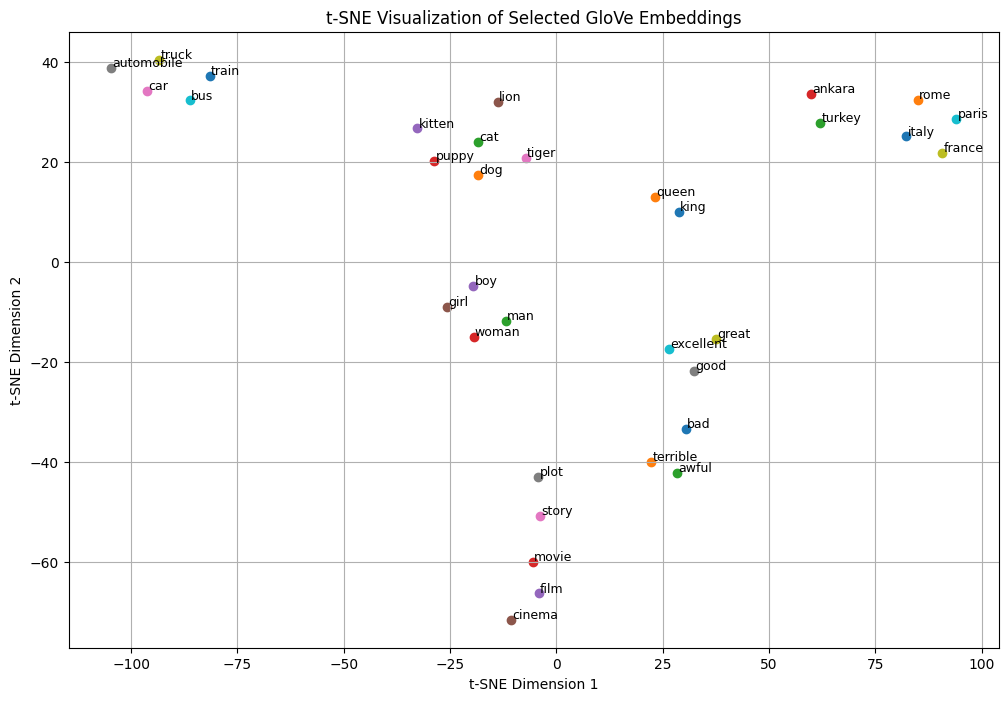

Words with similar meanings or categories tend to appear closer together in the visualization.


In [6]:
# Cell 1.5 - Visualize Selected Embeddings with t-SNE

words_to_plot = [
    "king", "queen", "man", "woman", "boy", "girl",
    "car", "automobile", "truck", "bus", "train",
    "dog", "cat", "puppy", "kitten", "lion", "tiger",
    "good", "great", "excellent", "bad", "terrible", "awful",
    "movie", "film", "cinema", "story", "plot",
    "france", "paris", "italy", "rome", "turkey", "ankara"
]

valid_words = [word for word in words_to_plot if word in word_to_vec]

X_embed = np.array([word_to_vec[word] for word in valid_words])

tsne = TSNE(
    n_components=2,
    perplexity=5,
    init="pca",
    random_state=42
)

X_2d = tsne.fit_transform(X_embed)

plt.figure(figsize=(12, 8))

for i, word in enumerate(valid_words):
    x, y = X_2d[i]
    plt.scatter(x, y)
    plt.text(x + 0.3, y + 0.3, word, fontsize=9)

plt.title("t-SNE Visualization of Selected GloVe Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True)
plt.show()

print("Words with similar meanings or categories tend to appear closer together in the visualization.")


# Question 2 - Sentiment Classification with Multinomial Naive Bayes

**50 points total**

In this question, you will download the UCI Sentiment Labelled Sentences dataset, preprocess the text, create Bag-of-Words features, train a Multinomial Naive Bayes classifier, and evaluate the classifier.

You must use `MultinomialNB(alpha=1.0)` for the classifier.

## Cell 2.1 - Download, Load, and Inspect the Dataset

**10 points**

**Goal:** Download the UCI sentiment dataset, combine Amazon, IMDb, and Yelp sentences into one DataFrame, and inspect the dataset.

In [7]:
# Cell 2.1 - Download, Load, and Inspect the Dataset

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

uci_url = "https://archive.ics.uci.edu/static/public/331/sentiment%2Blabelled%2Bsentences.zip"
zip_path = DATA_DIR / "sentiment_labelled_sentences.zip"
combined_csv_path = DATA_DIR / "sentiment_reviews_uci.csv"

if not zip_path.exists():
    request = Request(uci_url, headers={"User-Agent": "Mozilla/5.0"})
    response = urlopen(request)
    zip_path.write_bytes(response.read())


def find_file_in_zip(zip_file, filename_suffix):
    """Find a file inside a zip archive by suffix."""
    for filename in zip_file.namelist():
        if filename.endswith(filename_suffix):
            return filename

    raise FileNotFoundError(f"{filename_suffix} not found in zip archive.")


with zipfile.ZipFile(zip_path, "r") as zf:

    datasets = [
        ("amazon_cells_labelled.txt", "amazon"),
        ("imdb_labelled.txt", "imdb"),
        ("yelp_labelled.txt", "yelp")
    ]

    dataframes = []

    for filename, source_name in datasets:
        file_in_zip = find_file_in_zip(zf, filename)

        with zf.open(file_in_zip) as file:
            df = pd.read_csv(
                file,
                sep="\t",
                header=None,
                names=["text", "label"]
            )

        df["source"] = source_name
        dataframes.append(df)

sentiment_df = pd.concat(dataframes, ignore_index=True)

sentiment_df["label_name"] = sentiment_df["label"].map({
    0: "negative",
    1: "positive"
})

sentiment_df.to_csv(combined_csv_path, index=False)

print("First 5 rows:")
display(sentiment_df.head())

print(f"\nDataset shape: {sentiment_df.shape}")

print("\nClass distribution:")
print(sentiment_df["label_name"].value_counts())

print("\nSource distribution:")
print(sentiment_df["source"].value_counts())

positive_example = sentiment_df[sentiment_df["label"] == 1].iloc[0]["text"]
negative_example = sentiment_df[sentiment_df["label"] == 0].iloc[0]["text"]

print("\nPositive example:")
print(positive_example)

print("\nNegative example:")
print(negative_example)


First 5 rows:


,text,label,source,label_name
0,So there is no way for me to plug it in here i...,0,amazon,negative
1,"Good case, Excellent value.",1,amazon,positive
2,Great for the jawbone.,1,amazon,positive
3,Tied to charger for conversations lasting more...,0,amazon,negative
4,The mic is great.,1,amazon,positive



Dataset shape: (2748, 4)

Class distribution:
label_name
positive    1386
negative    1362
Name: count, dtype: int64

Source distribution:
source
amazon    1000
yelp      1000
imdb       748
Name: count, dtype: int64

Positive example:
Good case, Excellent value.

Negative example:
So there is no way for me to plug it in here in the US unless I go by a converter.


## Cell 2.2 - Basic Text Preprocessing

**10 points**

**Goal:** Clean the review text by lowercasing, handling common negation contractions, removing punctuation, and removing extra spaces while keeping negation words.

In [8]:
# Cell 2.2 - Basic Text Preprocessing

def preprocess_text(text):
    """
    Basic preprocessing for sentiment classification.

    Important:
    Keep negation words such as 'not', 'no', and 'never' because they are important for sentiment.
    """
    text = str(text).lower()

    contractions = {
        "can't": "can not",
        "won't": "will not",
        "n't": " not",
        "'re": " are",
        "'s": " is",
        "'ll": " will",
        "'ve": " have",
        "'d": " would"
    }

    for contraction, expanded in contractions.items():
        text = text.replace(contraction, expanded)

    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


sentiment_df["clean_text"] = sentiment_df["text"].apply(preprocess_text)

print("Original vs Cleaned Examples:\n")

for i in range(5):
    print(f"Original: {sentiment_df.iloc[i]['text']}")
    print(f"Cleaned : {sentiment_df.iloc[i]['clean_text']}")
    print("-" * 60)

negation_examples = sentiment_df[
    sentiment_df["clean_text"].str.contains(r"\b(not|no|never)\b", regex=True)
].head(5)

print("\nExamples containing negation words:\n")

display(negation_examples[["text", "clean_text"]])


Original vs Cleaned Examples:

Original: So there is no way for me to plug it in here in the US unless I go by a converter.
Cleaned : so there is no way for me to plug it in here in the us unless i go by a converter
------------------------------------------------------------
Original: Good case, Excellent value.
Cleaned : good case excellent value
------------------------------------------------------------
Original: Great for the jawbone.
Cleaned : great for the jawbone
------------------------------------------------------------
Original: Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!
Cleaned : tied to charger for conversations lasting more than 45 minutes major problems
------------------------------------------------------------
Original: The mic is great.
Cleaned : the mic is great
------------------------------------------------------------

Examples containing negation words:



/tmp/ipykernel_4632/1984967771.py:42: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  sentiment_df["clean_text"].str.contains(r"\b(not|no|never)\b", regex=True)


,text,clean_text
0,So there is no way for me to plug it in here i...,so there is no way for me to plug it in here i...
14,"The design is very odd, as the ear ""clip"" is n...",the design is very odd as the ear clip is not ...
16,I advise EVERYONE DO NOT BE FOOLED!,i advise everyone do not be fooled
20,I went on Motorola's website and followed all ...,i went on motorola is website and followed all...
27,I didn't think that the instructions provided ...,i did not think that the instructions provided...


## Cell 2.3 - Train/Test Split and Bag-of-Words Features

**10 points**

**Goal:** Split the cleaned text into training and test sets, then create unigram and bigram Bag-of-Words features using `CountVectorizer`.

In [9]:
# Cell 2.3 - Train/Test Split and Bag-of-Words Features

X_text = sentiment_df["clean_text"]
y = sentiment_df["label_name"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    min_df=2
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

feature_names = vectorizer.get_feature_names_out()

print(f"Number of training examples: {X_train.shape[0]}")
print(f"Number of test examples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Training matrix shape: {X_train.shape}")
print(f"Test matrix shape: {X_test.shape}")

print("\nFirst 20 feature names:")
print(feature_names[:20])


Number of training examples: 2198
Number of test examples: 550
Number of features: 4428
Training matrix shape: (2198, 4428)
Test matrix shape: (550, 4428)

First 20 feature names:
['10' '10 10' '10 minutes' '10 out' '100' '11' '12' '15' '15 minutes' '20'
 '20 minutes' '2005' '20th' '25' '25 years' '30' '30 minutes' '40'
 '40 minutes' '50']


## Cell 2.4 - Train Multinomial Naive Bayes and Inspect Important Tokens

**10 points**

**Goal:** Train `MultinomialNB(alpha=1.0)` and inspect the most predictive positive and negative words/bigrams.

In [10]:
# Cell 2.4 - Train Multinomial Naive Bayes and Inspect Important Tokens

clf = MultinomialNB(alpha=1.0)

clf.fit(X_train, y_train)

print("Model classes:")
print(clf.classes_)

feature_names = vectorizer.get_feature_names_out()

positive_class_index = list(clf.classes_).index("positive")
negative_class_index = list(clf.classes_).index("negative")

positive_scores = clf.feature_log_prob_[positive_class_index]
negative_scores = clf.feature_log_prob_[negative_class_index]

top_positive_indices = np.argsort(positive_scores)[-15:][::-1]
top_negative_indices = np.argsort(negative_scores)[-15:][::-1]

positive_features = pd.DataFrame({
    "feature": feature_names[top_positive_indices],
    "log_probability": positive_scores[top_positive_indices]
})

negative_features = pd.DataFrame({
    "feature": feature_names[top_negative_indices],
    "log_probability": negative_scores[top_negative_indices]
})

print("\nTop Positive Features:")
display(positive_features)

print("\nTop Negative Features:")
display(negative_features)


Model classes:
['negative' 'positive']

Top Positive Features:


,feature,log_probability
0,the,-3.334641
1,and,-3.697224
2,is,-3.913447
3,it,-4.312040
4,this,-4.459364
5,of,-4.487535
6,to,-4.613515
7,was,-4.710679
8,in,-4.835502
9,great,-4.926198



Top Negative Features:


,feature,log_probability
0,the,-3.376026
1,and,-4.089134
2,is,-4.150095
3,not,-4.152956
4,it,-4.261825
5,to,-4.317668
6,was,-4.447346
7,of,-4.451200
8,this,-4.474638
9,that,-4.945433


## Cell 2.5 - Evaluate and Interpret the Classifier

**10 points**

**Goal:** Evaluate the Naive Bayes classifier using accuracy, confusion matrix, classification report, and misclassified examples.

Test Accuracy: 0.8164

Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.84      0.82       273
    positive       0.83      0.79      0.81       277

    accuracy                           0.82       550
   macro avg       0.82      0.82      0.82       550
weighted avg       0.82      0.82      0.82       550



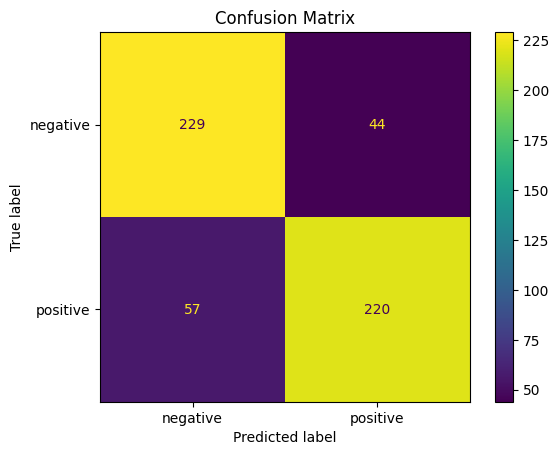


Misclassified Examples:


,text,true_label,predicted_label
0,very unreliable service from t mobile,negative,positive
8,the portion was huge,positive,negative
13,food was so gooodd,positive,negative



Interpretation:
Some reviews contain sarcasm, mixed sentiment, or context-dependent expressions that are difficult for Bag-of-Words models to capture.


In [11]:
# Cell 2.5 - Evaluate and Interpret the Classifier

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=clf.classes_
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

results_df = pd.DataFrame({
    "text": X_test_text.values,
    "true_label": y_test.values,
    "predicted_label": y_pred
})

misclassified = results_df[
    results_df["true_label"] != results_df["predicted_label"]
]

print("\nMisclassified Examples:")
display(misclassified.head(3))

print("\nInterpretation:")
print("Some reviews contain sarcasm, mixed sentiment, or context-dependent expressions that are difficult for Bag-of-Words models to capture.")
